In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46477")
client

<Client: 'tcp://127.0.0.1:46477' processes=6 threads=48, memory=48.00 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/app/SWOT/"

In [4]:
ipass = 4
ds04 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % ipass))
ds04.coords["num_lines"] = ("num_lines",range(len(ds04.num_lines)))
ds04.coords["num_pixels"] = ("num_pixels",range(len(ds04.num_pixels)))
ds04

<xarray.Dataset> Size: 582MB
Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>

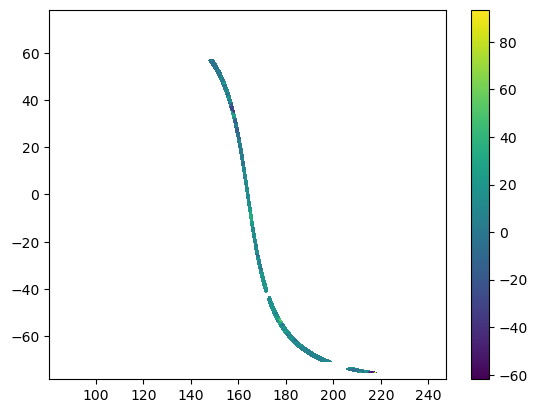

In [5]:
fig, ax = plt.subplots()
im = ax.pcolor(ds04.longitude, ds04.latitude,
          ds04.ssha_detided.isel(cycle_num=1), 
          rasterized=True
         )
fig.colorbar(im)
plt.show()

In [6]:
inp = 3

In [7]:
maskn = xr.DataArray(ds04.latitude.where(ds04.latitude>5.).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
masks = xr.DataArray(ds04.latitude.where(ds04.latitude<-5.).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
dsns = ds04.where(~maskn,drop=True)
dsns = xr.concat([dsns, ds04.where(~masks,drop=True)
                 ], "num_lines"
                ).sortby("num_lines")
dsns

<xarray.Dataset> Size: 550MB
Dimensions:       (cycle_num: 105, num_lines: 9312, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 74kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4657, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4657, 69), meta=np.ndarray>
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 540MB dask.array<chunksize=(1, 4657, 69), meta=np.ndarray>

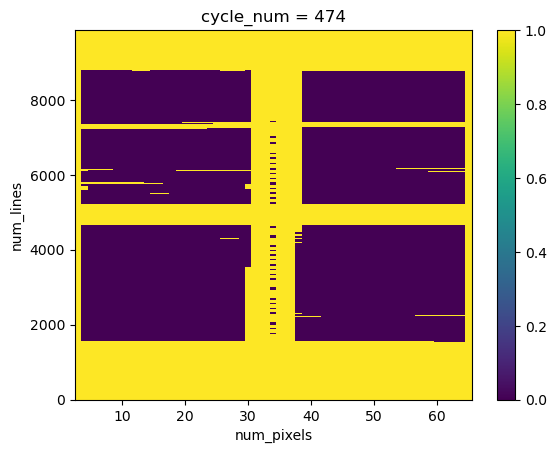

In [8]:
mask04 = xr.DataArray(dsns.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                     coords=dsns.ssha_detided.isel(cycle_num=0).coords
                    )
mm04 = xr.DataArray(mask04.where(mask04<.5
                              ).to_masked_array().mask,
                   dims=dsns.ssha_detided.isel(cycle_num=0).dims, 
                   coords=dsns.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm04.plot(rasterized=True)

In [9]:
r_ref = (~mm04).sum() / np.prod(mm04.shape)
r_ref

<xarray.DataArray ()> Size: 8B
array(0.588834)
Coordinates:
    cycle_num  int64 8B 474

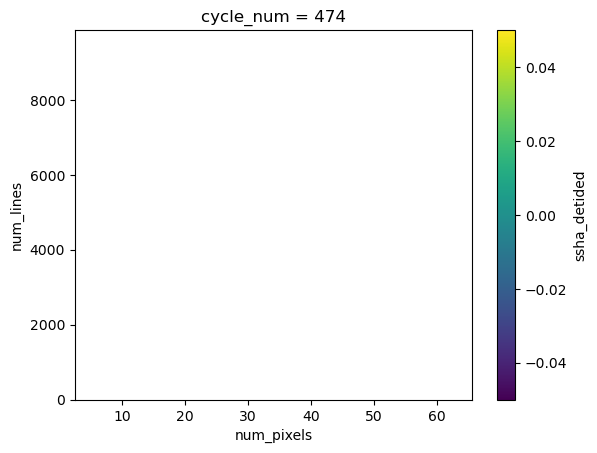

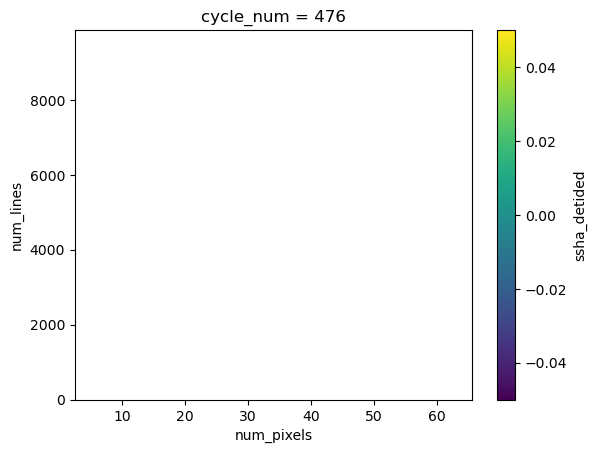

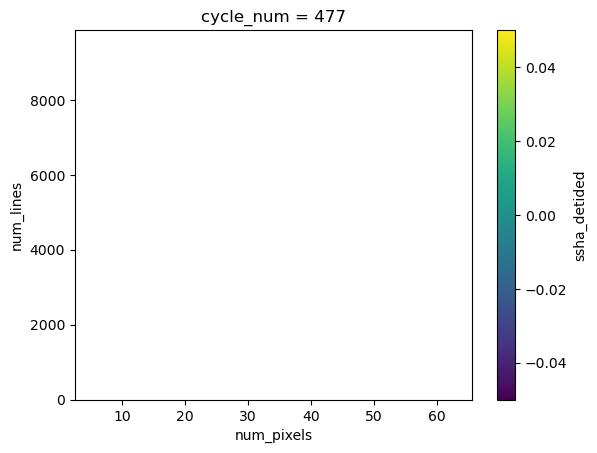

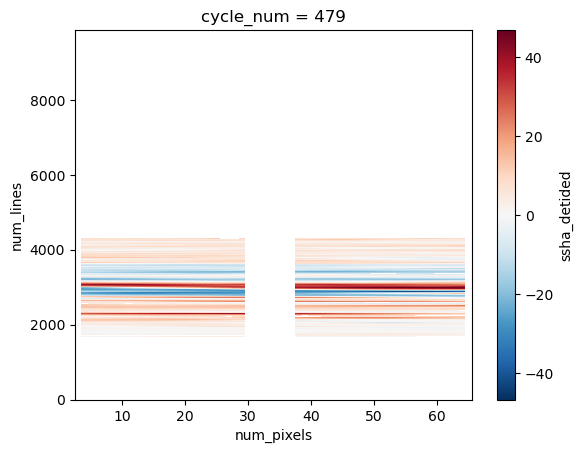

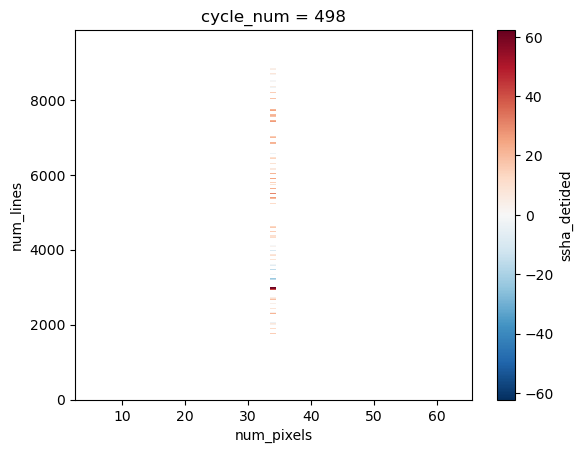

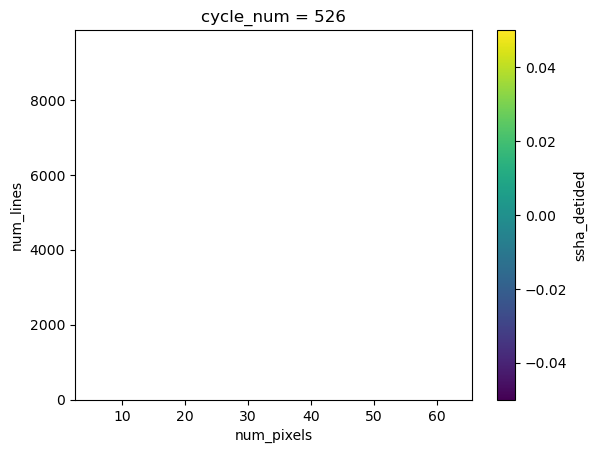

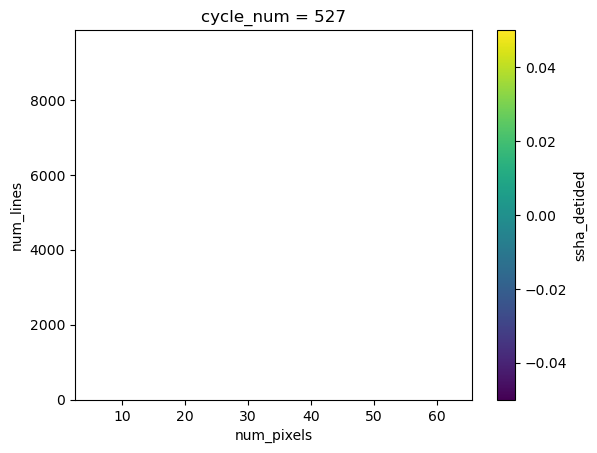

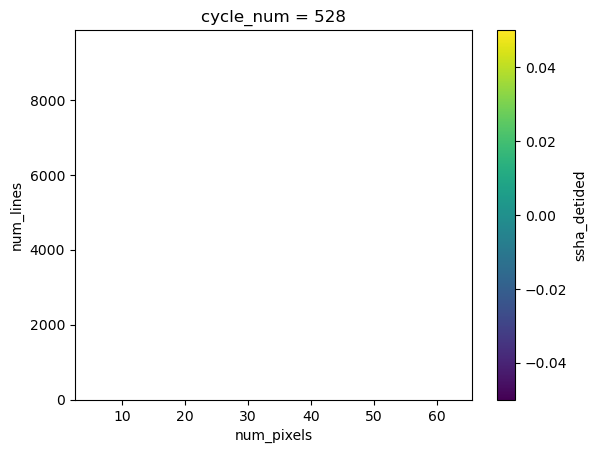

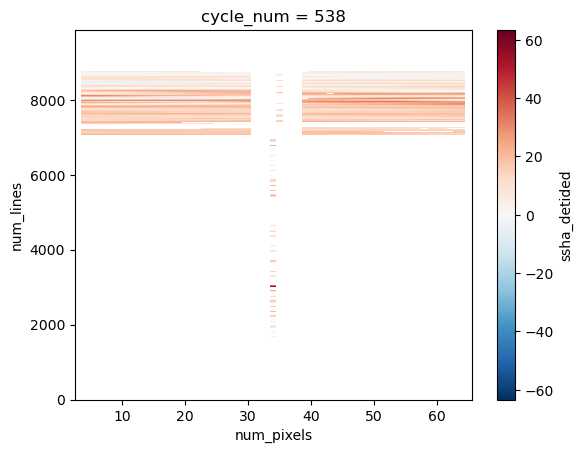

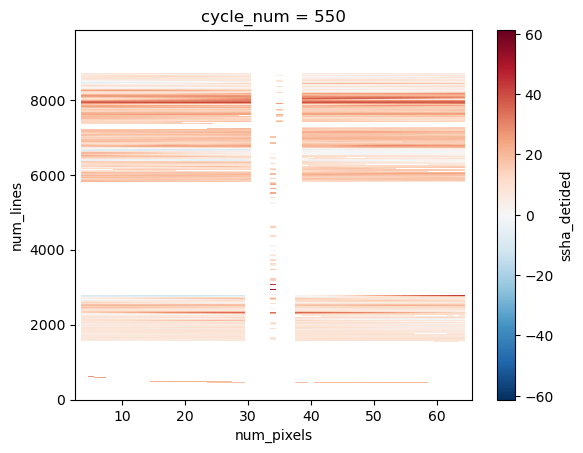

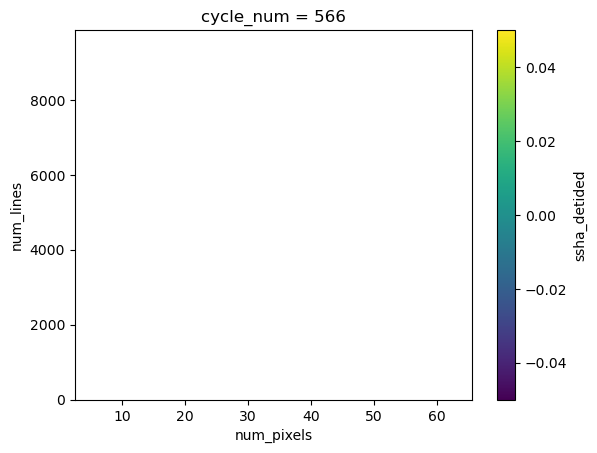

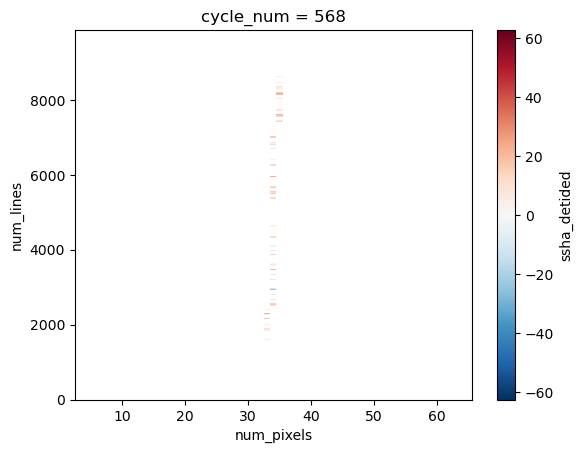

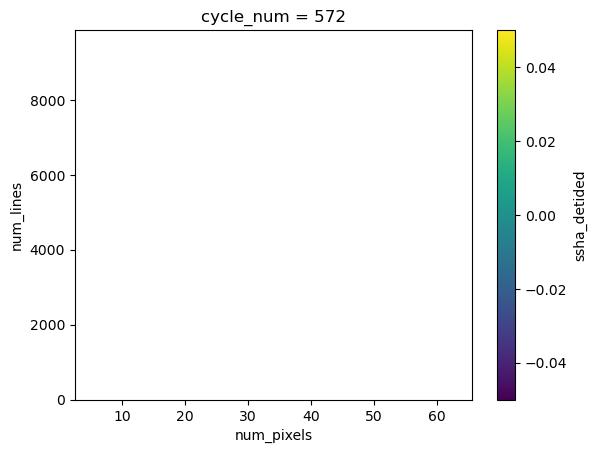

<xarray.DataArray 'ssha_detided' (cycle_num: 92, num_lines: 9312, num_pixels: 63)> Size: 432MB
dask.array<concatenate, shape=(92, 9312, 63), dtype=float64, chunksize=(1, 4657, 63), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 736B 475 478 480 481 482 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 0 1 2 3 4 5 ... 9855 9856 9857 9858 9859
  * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4657, 63), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4657, 63), meta=np.ndarray>

In [10]:
ic = 0
for cc in dsns.cycle_num:
    
    ssha = dsns.ssha_detided.sel(cycle_num=cc).isel(num_pixels=slice(inp,-inp))
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        R04 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        R04 = xr.concat([R04, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref:
        if ic == 0:
            H04 = ssha
        else:
            try:
                H04 = xr.concat([H04, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    else:
        ssha.plot(rasterized=True)
        plt.show()
    del ssha, mask, array

H04.coords["cycle_num"] = ("cycle_num",
                           R04.where(R04>0.7*r_ref, drop=True).cycle_num.data
                          )
H04

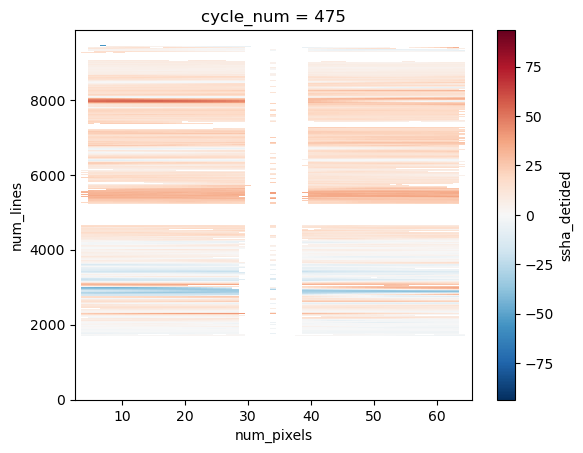

In [11]:
H04.isel(cycle_num=0).plot(rasterized=True)

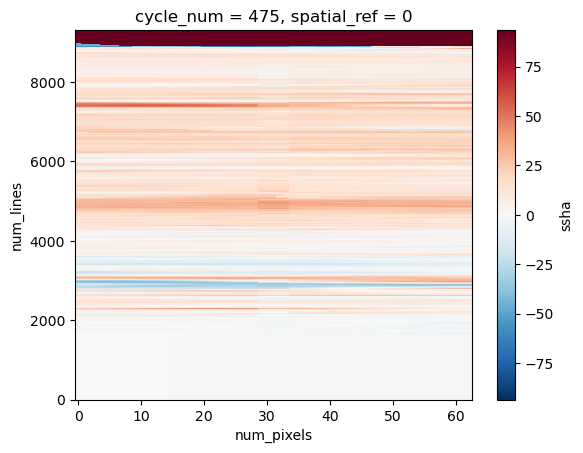

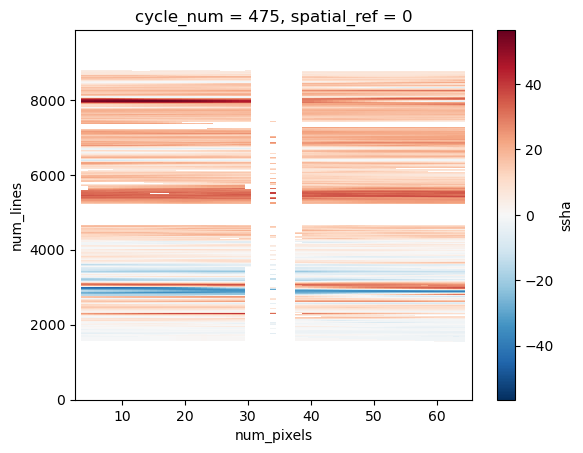

In [12]:
dsH04 = H04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                               'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsH04.coords["y"] = ("y",range(len(dsH04.y)))
dsH04.coords["x"] = ("x",range(len(dsH04.x)))
if not dsH04.rio.crs:
    dsH04 = dsH04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsH04.ssha.rio.nodata is None:
    dsH04["ssha"] = dsH04.ssha.rio.write_nodata(np.nan)
_H04_exterp = dsH04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha
_H04_exterp.isel(cycle_num=0).plot(rasterized=True)
plt.show()

H04_exterp = _H04_exterp.where(mm04!=1)
H04_exterp.isel(cycle_num=0).plot(rasterized=True)
plt.show()

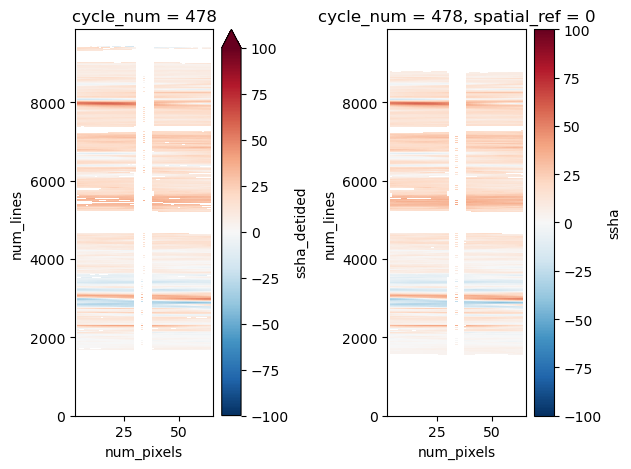

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_tight_layout(True)

dsns.ssha_detided.sel(cycle_num=478
                     ).isel(num_pixels=slice(inp,-inp)
                           ).plot(ax=ax1, rasterized=True, vmax=1e2)
H04_exterp.sel(cycle_num=478).plot(ax=ax2, rasterized=True, vmax=1e2)

In [14]:
fscale = np.ceil(14/np.sqrt(12)/2)
print(fscale)

3.0


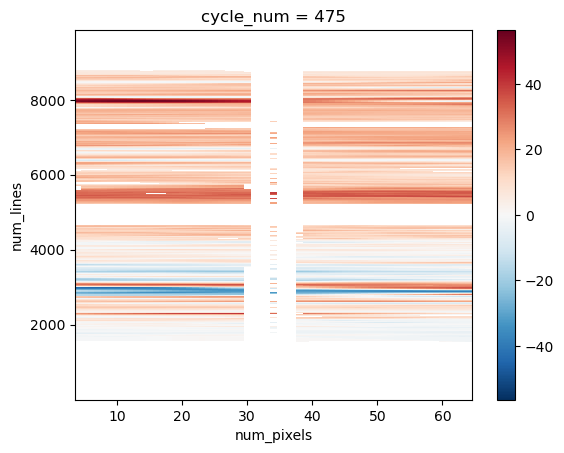

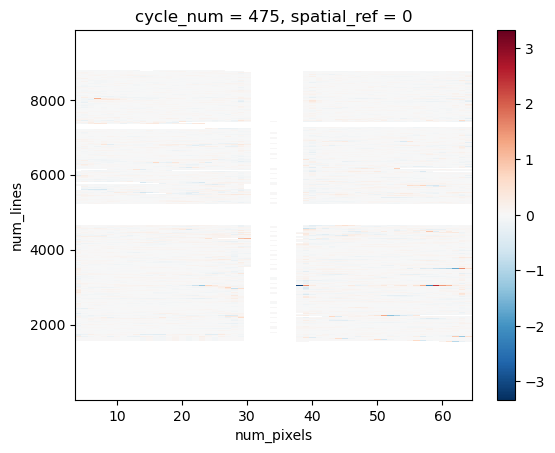

In [15]:
wet_mask = xr.DataArray(mm04.where(mm04!=0).to_masked_array().mask.astype(np.float64),
                        dims=mm04.dims, coords=mm04.coords
                       ).reset_coords(drop=True)

regular_filter = gcm_filters.Filter(
    filter_scale=fscale,
    dx_min=1,
    filter_shape=gcm_filters.FilterShape.GAUSSIAN,
    grid_type=gcm_filters.GridType.REGULAR_WITH_LAND,
    grid_vars={'wet_mask': wet_mask,
    }
)

_sshm = regular_filter.apply(_H04_exterp.chunk({'num_lines':-1,'num_pixels':-1}), 
                         dims=['num_lines','num_pixels']
                        ).reset_coords(drop=True).where(mm04!=1).chunk({"cycle_num":1,
                                                         "num_lines":-1,"num_pixels":-1}
                                                       ).isel(num_pixels=slice(1,-1),
                                                              num_lines=slice(1,-1)
                                                             )
_sshm.isel(cycle_num=0).plot()
plt.show()
(_H04_exterp.isel(num_pixels=slice(1,-1),num_lines=slice(1,-1))
 - _sshm).isel(cycle_num=0).plot()
plt.show()
dsave = _sshm.to_dataset(name="ssha"
                        ).to_zarr(op.join(ddir,
                      'CalVal/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                      % (ipass,int(fscale))
                                         ), mode='w'
                                 )

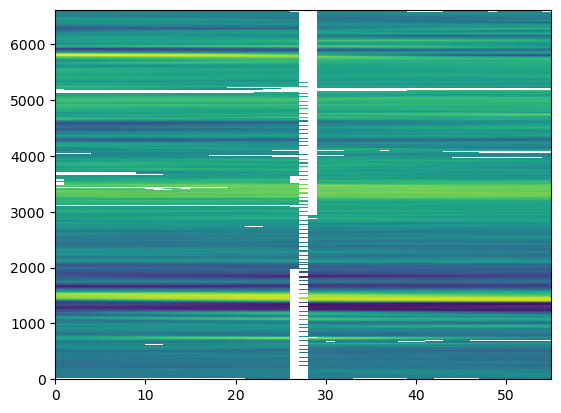

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 9310, num_pixels: 61)> Size: 477MB
 dask.array<mul, shape=(105, 9310, 61), dtype=float64, chunksize=(105, 847, 7), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 6621, num_pixels: 55)> Size: 306MB
 dask.array<where, shape=(105, 6621, 55), dtype=float64, chunksize=(105, 846, 7), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 53kB 1545 1548 154

In [16]:
h_interp = xr.open_zarr(op.join(ddir,
                        'CalVal/Pass%03d/ssha_rawgrid_%02dpoints.zarr' 
                        % (ipass,fscale))
                       ).ssha.interp(cycle_num=ds04.cycle_num, 
                                     method="slinear",
                                     kwargs={"fill_value": "extrapolate"}
                                    ) * 1e-2   # centimeters to meters
# h_interp.coords["num_pixels"] = ("num_pixels", range(len(h_interp.num_pixels)))
# h_interp.coords["num_lines"] = ("num_lines", range(len(h_interp.num_lines)))
# maskh = xr.DataArray(h_interp.to_masked_array().mask,
#                      dims=h_interp.dims, coords=h_interp.coords
#                     )
h_dropped = h_interp.where(mm04.isel(num_pixels=slice(1,-1),
                                     num_lines=slice(1,-1)
                                    ).reset_coords(drop=True)!=1, drop=True)

plt.pcolormesh(h_dropped.isel(cycle_num=10).data,rasterized=True)
plt.show()
h_interp, h_dropped

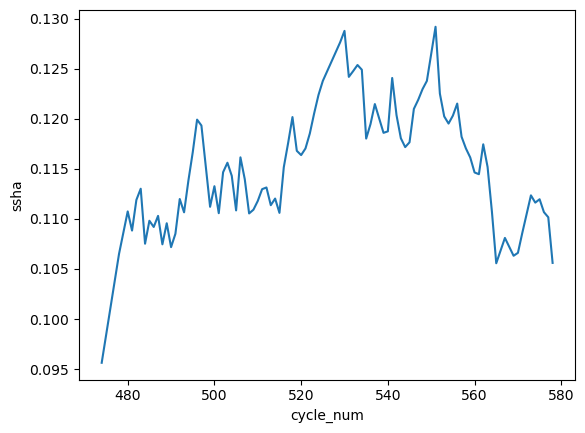

In [17]:
h_dropped.mean(['num_lines','num_pixels'],skipna=True).plot()

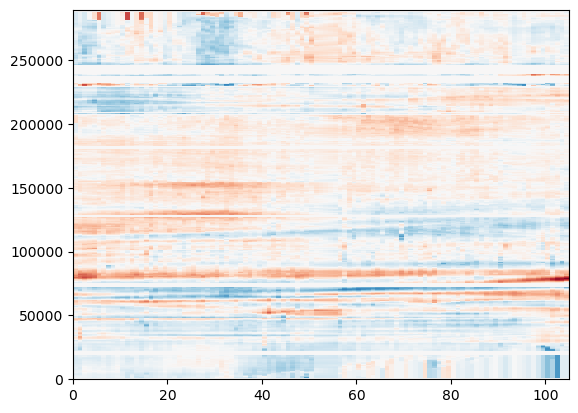

<xarray.DataArray 'ssha' (z: 289464, cycle_num: 105)> Size: 243MB
dask.array<transpose, shape=(289464, 105), dtype=float64, chunksize=(10000, 105), chunktype=numpy.ndarray>
Coordinates:
  * z           (z) object 2MB MultiIndex
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
    latitude    (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 2MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * num_lines   (z) int64 2MB 944 944 944 944 944 ... 9811 9811 9811 9811 9811
  * num_pixels  (z) int64 2MB 4 5 6 7 8 9 10 11 12 ... 57 58 59 60 61 62 63 64

In [22]:
zchunk = 10000
h_stacked = (h_dropped 
             - h_dropped.mean(['num_lines','num_pixels'],skipna=True)
            ).stack(z=('num_lines','num_pixels')
                          ).chunk({'z':zchunk}).fillna(0.)
# h_stacked = h_interp.stack(z=("YC", "XC")
#                           ).chunk({'z':zchunk}).fillna(0.)

fig, ax = plt.subplots()
ax.pcolormesh(h_stacked.T.values, 
              rasterized=True,  
              vmax=.4, vmin=-.4, cmap='RdBu_r')
plt.show()
h_stacked.T

In [23]:
nh = 24.*3600.
window_lengths = np.ceil( np.array([9, 10, 30, 60])
                         * 86400/nh ).astype(int) # 24 hourly
step_sizes = np.array([1, 1, 1, 1])
print(window_lengths, "[days]")
nh / 86400.

[ 9 10 30 60] [days]


1.0

In [24]:
fit = True

In [ ]:
svd_ranks = [4, 4, 10, 12]
if len(svd_ranks) != len(window_lengths):
    print("######### WRONG LENGTHS #########")
suppress_growth = True
transform_method = "absolute"
# n_components_array = [2] * len(window_lengths)
global_svd_array = [False] * len(window_lengths)
# kern_method = "flat"
# real_eig_limit = 0.5
# pydmd_kwargs = {
#     "eig_constraints": {"conjugate_pairs", "limited"},
#     "real_eig_limit": real_eig_limit,
# }

dmd = mrCOSTS(
    svd_rank_array=svd_ranks,
    window_length_array=window_lengths,
    step_size_array=step_sizes,
    global_svd_array=global_svd_array,
    cluster_sweep=True,
    transform_method=transform_method,
    # kern_method=kern_method,
    # relative_filter_length=relative_filter_length,
    # pydmd_kwargs=pydmd_kwargs,
)

if fit:
    dmd.fit(h_stacked.values.T, 
            np.atleast_2d(np.arange(len(h_stacked.cycle_num)
                                   ) * nh)
           )

_________________________________________________
Fitting window length = 9
0 of 97


In [ ]:
if fit:
    # dmd.to_netcdf(op.join(ddir, 
    #                       "SWOT/CalVal/mrCOSTS_h/%02dhourly/%02d_fit"
    #                       % (nh,len(window_lengths))
    #                      )
    #              )
    dmd.to_netcdf(op.join(ddir, 
                  "CalVal/mrCOSTS/Pass%03d_%02d_raw_%02dpoints"
                  % (ipass,len(window_lengths),2)
                         )
                 )
else:
    mrc = glob.glob(op.join(ddir, 
                "CalVal/mrCOSTS/Pass%03d_04_raw_*.nc"
                % (ipass)
                           )
                   )
    print(mrc)
    dmd = mrCOSTS()
    dmd.from_netcdf(mrc)

In [20]:
dmd.multi_res_interp()
dmd._da_omega

<xarray.DataArray 'omega' (window_length: 4, window_time_means: 97, svd_rank: 12)> Size: 74kB
array([[[            nan           +nanj,
                     nan           +nanj,
          3.36275414e-06+1.91569096e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
          3.37847141e-07+1.84778329e-05j, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [ 6.22250258e-07+1.86616283e-05j,
          6.22250258e-07-1.86616283e-05j,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        ...,
        [            nan           +nanj,
...
                     nan           +nanj],
        ...,
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj],
        [            nan           +nanj,
                     nan           +nanj,
                     nan           +nanj, ...,
                     nan           +nanj,
                     nan           +nanj,
                     nan           +nanj]]], shape=(4, 97, 12))
Coordinates:
  * window_length        (window_length) int64 32B 9 10 30 60
  * window_time_means    (window_time_means) float64 776B 3.456e+05 ... 8.64e+06
  * svd_rank             (svd_rank) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    slide                (window_length, window_time_means) float64 3kB 0.0 ....
    decomposition_level  (window_length) int64 32B 0 1 2 3

fitting n_components = 4
fitting n_components = 5
fitting n_components = 6
fitting n_components = 7
fitting n_components = 8
fitting n_components = 9
fitting n_components = 10
fitting n_components = 11
fitting n_components = 12
fitting n_components = 13
fitting n_components = 14
fitting n_components = 15
fitting n_components = 16
fitting n_components = 17
fitting n_components = 18
fitting n_components = 19
fitting n_components = 20
fitting n_components = 21
fitting n_components = 22
fitting n_components = 23
fitting n_components = 24
fitting n_components = 25
fitting n_components = 26
fitting n_components = 27
fitting n_components = 28
fitting n_components = 29
Optimal silhouette score is = 9


Text(0, 0.5, 'Silhouette score (-), (1 is best, -1 is worst)')

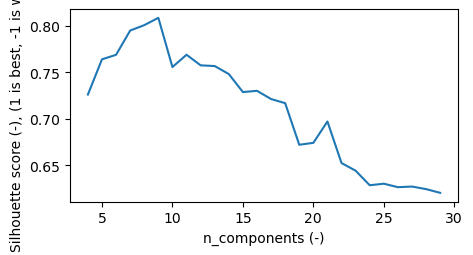

In [21]:
n_components_range = np.arange(4, 30)
scores, n_optimal = dmd.global_cluster_hyperparameter_sweep(
    n_components_range,
    transform_method="log10",
)

print("Optimal silhouette score is = {}".format(n_optimal))
plt.figure(figsize=(5, 2.5))
plt.plot(n_components_range, scores)
plt.gca().set_xlabel("n_components (-)")
plt.gca().set_ylabel("Silhouette score (-), (1 is best, -1 is worst)")

In [22]:
# n_ops = 10
cluster_centroids, omega_classes, omega_array = dmd.global_cluster_omega(
    n_optimal,
    # n_ops,
    transform_method="log10"
)
cluster_centers_periods = 1 / (10 ** (cluster_centroids) / (2 * np.pi))

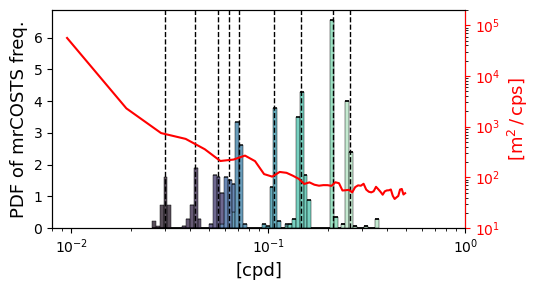

In [23]:
x_trans = (2 * np.pi / 10**omega_array / 86400.)**-1

hue_order = np.arange(len(np.unique(omega_classes))).astype(str)
cluster_centers = 1 / ((10 ** cluster_centroids) / (2 * np.pi) / 86400.)

# Make a continuous color palette with the brightest and darkest excluded
palette = sns.color_palette("mako", len(cluster_centers) + 2)
# palette = palette[1:-1]


Fh = xrft.power_spectrum(h_dropped[...,::150,10::40
                         ].chunk({'cycle_num':-1}
                                ).assign_coords({'cycle_num':
                                                 np.arange(len(h_interp.cycle_num)) 
                                                 * nh}
                                               ), 
                         dim='cycle_num', window='hann', window_correction=True
                        ).astype(np.single)

from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(5.5, 3))
ax2 = ax.twinx()
fig.set_tight_layout(True)

ax2.plot(Fh.freq_cycle_num.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                               )*86400, 
         Fh.isel(freq_cycle_num=slice(len(Fh.freq_cycle_num)//2+1,None)
                ).mean(['num_pixels','num_lines'],skipna=True)*2,
         c='r', label=r"Fourier")

ax.set_xscale("log")
ax2.set_yscale("log")

sns.histplot(
    # x=((10**omega_array) / (2 * np.pi) / 86400.),
    x=x_trans,
    hue=omega_classes,
    hue_order=hue_order,
    common_bins=True,
    common_norm=True,
    stat="density",
    multiple="stack",
    bins=60,
    palette=ListedColormap(palette),
    legend=False,
    ax=ax
)

ax.set_xlabel(r"[cpd]", fontsize=13)
ax.set_ylabel("PDF of mrCOSTS freq.", fontsize=13)
ax2.set_ylabel("[m$^2\,/\,$cps]", fontsize=13, c='r')

ax.set_xlim([8e-3,1e0])
# ax2.set_xlim([8e-3,1.5e1])
ax2.set_ylim([1e1,2e5])

ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', colors='red')

[
    ax.axvline((2 * np.pi / (10**c) / 86400)**-1, color="k", ls="--", lw=1)
    for nc, c in enumerate(cluster_centroids)
];

plt.savefig(op.join(ddir,'Figs/SWOT_Pass%03d-raw_mrCOSTS_hist-%02d_%02dpoints.pdf' 
                    % (ipass,len(window_lengths),int(fscale)))
           )

In [24]:
np.where((2 * np.pi / (10**cluster_centroids) 
          / 86400)**-1 <= 1e-1)

(array([0, 1, 2, 3, 4]),)

In [25]:
omega_classes_list = dmd.multi_res_deterp()

In [40]:
xr_background = dmd.get_background()
print(xr_background.shape, h_stacked)

ds_global_background = xr.DataArray(xr_background, dims=h_stacked.T.dims,
                            coords=h_stacked.T.coords
                           ).unstack().chunk({'cycle_num':1}
                                            ).interp(
    num_pixels=mm02.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
    num_lines=mm02.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                            ).where(mm02.isel(num_pixels=slice(1,-1),
                                                              num_lines=slice(1,-1)
                                                             )!=1
                                                   )
ds_global_background.chunk(
        {'num_pixels':-1, 'num_lines':-1}
).to_dataset(name='background'
            ).to_zarr(op.join(ddir,
            'CalVal/Pass%03d/background-raw_%02dpoints.zarr' 
                              % (ipass, fscale)),
                              mode='w')

(397264, 105) <xarray.DataArray 'ssha' (cycle_num: 105, z: 397264)> Size: 334MB
dask.array<where, shape=(105, 397264), dtype=float64, chunksize=(105, 10000), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * z           (z) object 3MB MultiIndex
    latitude    (z) float64 3MB dask.array<chunksize=(10000,), meta=np.ndarray>
    longitude   (z) float64 3MB dask.array<chunksize=(10000,), meta=np.ndarray>
  * num_lines   (z) int64 3MB 2 2 2 2 2 2 2 ... 9278 9278 9278 9278 9278 9278
  * num_pixels  (z) int64 3MB 4 5 6 7 8 9 10 11 12 ... 57 58 59 60 61 62 63 64


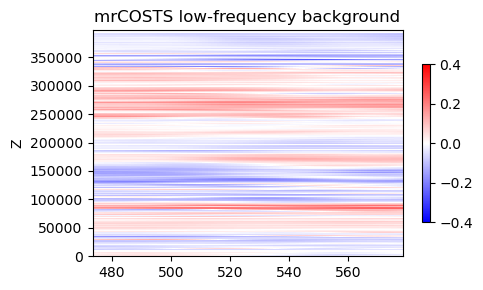

In [37]:
fig, ax = plt.subplots(figsize=(5, 3))
fig.set_tight_layout(True)
im = ax.pcolormesh(
    h_stacked.cycle_num,
    np.arange(len(h_stacked.z)), 
    xr_background, 
    vmin=-.4, vmax=.4, cmap="bwr",
    rasterized=True
)
ax.set_title("mrCOSTS low-frequency background")
ax.set_ylabel("Z")
# fig.autofmt_xdate()
fig.colorbar(im, shrink=.7)

In [38]:
xr_sep = dmd.global_scale_reconstruction()

In [43]:
for ncl_center, cl_center in enumerate(cluster_centers_periods):
    
    ds_xr_sep = xr.DataArray(
        xr_sep.real[:, ncl_center],
        dims=["decomp_level", "z", "cycle_num"],
        coords=[
            np.arange(len(dmd.costs_array)),
            # np.arange(n_optimal),
            h_stacked.z,
            h_stacked.cycle_num,
        ],
    )
    
    for dd in ds_xr_sep.decomp_level:
        if dd == 0:
            sep_unstacked = ds_xr_sep.sel(decomp_level=dd
                                 ).unstack().chunk({'cycle_num':1})
        else:
            tmp = ds_xr_sep.sel(decomp_level=dd
                               ).unstack().chunk({'cycle_num':1})
            sep_unstacked = xr.concat([sep_unstacked,
                                       tmp
                                      ], 'decomp_level'
                                     )
            del tmp

    ds_global_separation = sep_unstacked.interp(
        num_pixels=mm02.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
        num_lines=mm02.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                               ).where(mm02.isel(num_pixels=slice(1,-1),
                                                                 num_lines=slice(1,-1)
                                                                )!=1
                                                      )

    ds_cluster_centers = xr.DataArray(
        np.array([1 / (10 ** (cluster_centroids[ncl_center]) / (2 * np.pi)),]),
        dims=["cluster"],
        # coords=[np.arange(n_optimal)],
        coords=[np.array([ncl_center,])],
    )
    ds_cluster_centers.attrs["units"] = "s"
    ds_cluster_centers.attrs["long_name"] = "Central period of each period band"
    
    ds_global_separation = ds_global_separation.to_dataset(name="frequency_bands")
    ds_global_separation["frequency_bands"].attrs["units"] = "m"
    ds_global_separation["frequency_bands"].attrs["long_name"] = "mrCOSTS"
    
    ds_global_separation.coords["cluster_centers"] = ds_cluster_centers

    if ncl_center == 0:
        print(ds_global_separation)
        
    ds_global_separation.chunk(
                {'num_pixels':-1, 'num_lines':-1}
                ).to_zarr(op.join(ddir,
    'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                      % (ipass, ncl_center, fscale)),
                      mode='w')
    print(ncl_center)

<xarray.Dataset> Size: 2GB
Dimensions:          (decomp_level: 4, cycle_num: 105, num_pixels: 61,
                      num_lines: 9310, cluster: 1)
Coordinates:
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_pixels       (num_pixels) int64 488B 4 5 6 7 8 9 ... 59 60 61 62 63 64
  * num_lines        (num_lines) int64 74kB 1 2 3 4 5 ... 9855 9856 9857 9858
  * cluster          (cluster) int64 8B 0
    latitude         (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 61), meta=np.ndarray>
    longitude        (num_lines, num_pixels) float64 5MB dask.array<chunksize=(4656, 61), meta=np.ndarray>
    cluster_centers  (cluster) float64 8B 2.902e+06
Data variables:
    frequency_bands  (decomp_level, cycle_num, num_lines, num_pixels) float64 2GB dask.array<chunksize=(1, 1, 9310, 61), meta=np.ndarray>
0
1
2
3
4
5
6
7
8


In [26]:
xr_global_reconstruction = dmd.global_reconstruction()
glb_unstacked = xr.DataArray(
    data=xr_global_reconstruction.real, 
    dims=h_stacked.T.dims,
    coords=h_stacked.T.coords
).unstack()

da_global_reconstruction = glb_unstacked.interp(
        num_pixels=mm02.drop("cycle_num").isel(num_pixels=slice(1,-1)).num_pixels,
        num_lines=mm02.drop("cycle_num").isel(num_lines=slice(1,-1)).num_lines
                                               ).where(mm02.isel(num_pixels=slice(1,-1),
                                                                 num_lines=slice(1,-1)
                                                                )!=1
                                                      )
da_global_reconstruction.attrs["units"] = "m"
da_global_reconstruction.attrs["long_name"] = r"SWOT SSH"

da_global_reconstruction.chunk(
    # {'lat':100, 'lon':100}
).to_dataset(name='SSH').to_zarr(op.join(ddir,
                    'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                      % (ipass, fscale)),
                      mode='w')

# Extract the slow component

In [27]:
for i in range(30):
    if i == 0:
        dsc = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                                    % (ipass,i,fscale))
                           )

    else:
        try:
            dsc = xr.concat([dsc,xr.open_zarr(op.join(ddir,
                    'CalVal/Pass%03d/cluster%02d-raw_%02dpoints.zarr' 
                                  % (ipass,i,fscale)))
                            ], 'cluster')

        except:
            pass
    
dsC = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                           % (ipass,fscale))
                  )

dsb = xr.open_zarr(op.join(ddir,
            'CalVal/Pass%03d/background-raw_%02dpoints.zarr' 
                           % (ipass,fscale))
                  )

dsc

<xarray.Dataset> Size: 17GB
Dimensions:          (cluster: 9, decomp_level: 4, cycle_num: 105,
                      num_lines: 9310, num_pixels: 61)
Coordinates:
  * cluster          (cluster) int64 72B 0 1 2 3 4 5 6 7 8
  * decomp_level     (decomp_level) int64 32B 0 1 2 3
  * cycle_num        (cycle_num) int64 840B 474 475 476 477 ... 575 576 577 578
  * num_lines        (num_lines) int64 74kB 1 2 3 4 5 ... 9855 9856 9857 9858
  * num_pixels       (num_pixels) int64 488B 4 5 6 7 8 9 ... 59 60 61 62 63 64
    cluster_centers  (cluster) float64 72B dask.array<chunksize=(1,), meta=np.ndarray>
    latitude         (num_lines, num_pixels) float64 5MB 78.2 78.18 ... -78.2
    longitude        (num_lines, num_pixels) float64 5MB 106.1 106.1 ... 272.9
Data variables:
    frequency_bands  (cluster, decomp_level, cycle_num, num_lines, num_pixels) float64 17GB dask.array<chunksize=(1, 1, 1, 9310, 61), meta=np.ndarray>

In [28]:
n_cluster = len(np.where((2 * np.pi / (10**cluster_centroids) 
                          / 86400.)**-1 <= 1e-1)[0])
print(n_cluster)
low = (dsb.background 
       + dsc.frequency_bands.isel(cluster=slice(None,n_cluster)
                                 ).sum(['cluster','decomp_level'])
      )

tot = xr.open_zarr(op.join(ddir,
                   'CalVal/Pass%03d/Total-raw_%02dpoints.zarr' 
                   % (ipass,fscale))
                  ).SSH

low

5


<xarray.DataArray (cycle_num: 105, num_lines: 9310, num_pixels: 61)> Size: 477MB
dask.array<add, shape=(105, 9310, 61), dtype=float64, chunksize=(1, 9310, 61), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB 78.2 78.18 ... -78.18 -78.2
    longitude   (num_lines, num_pixels) float64 5MB 106.1 106.1 ... 272.9 272.9

# Compute geostrophy

In [ ]:
grav = 9.8
yy, xx = np.mgrid[low.latitude.min(skipna=True).values:low.latitude.max(skipna=True).values:np.abs(low.latitude.diff('num_lines').min(skipna=True).values),
                  low.longitude.min(skipna=True).values:low.longitude.max(skipna=True).values:np.abs(low.longitude.diff('num_pixels').min(skipna=True).values)
                 ]
lon = griddata((low.latitude.values.flatten(),
                low.longitude.values.flatten()
               ), 
               low.longitude.values.flatten(), 
               (yy, xx), method=meth
              )
lat = griddata((low.latitude.values.flatten(),
                low.longitude.values.flatten()
               ), 
               low.latitude.values.flatten(), 
               (yy, xx), method=meth
              )
for cc in low.cycle_num:
    ssh = griddata((low.latitude.values.flatten(),
                    low.longitude.values.flatten()
                   ), 
                   low.sel(cycle_num=cc).values.flatten(), 
                   (yy, xx), method=meth
                  )
    if cc == low.cycle_num[0]:
        low_gridded = xr.DataArray(ssh, dims=['YC','XC'], 
                           coords={'YC':np.mean(yy, axis=1),
                                   'XC':np.mean(xx, axis=0)}
                          )
    else:
        low_gridded = xr.concat([low_gridded, 
                          xr.DataArray(ssh, dims=['YC','XC'], 
                           coords={'YC':np.mean(yy, axis=1),
                                   'XC':np.mean(xx, axis=0)}
                          )
                         ], "cycle_num")
    del ssh
low_gridded.coords['cycle_num'] = low.cycle_num
print(low_gridded)
####################
xx, yy = np.meshgrid(low_gridded.XC, low_gridded.YC)
dx = gsw.distance(xx, yy, p=0, axis=-1)
dy = gsw.distance(xx, yy, p=0, axis=0)

cori = gsw.f(low_gridded.YC)
coriY = gsw.f(low_gridded.YC.rolling(YC=2).mean().dropna("YC"))

u = -(grav * low_gridded.diff("YC")
      / coriY
      / dy)
v = (grav * low_gridded.diff("XC")
     / cori 
     / dx)

u_x = u.diff("XC").values / (.5*(dx[1:] + dx[:-1]))
v_y = v.diff("YC").values / (.5*(dy[:,1:] + dy[:,:-1]))
u_x = .25*(u_x[...,:-1,:-1] + u_x[...,1:,:-1] + u_x[...,1:,1:] + u_x[...,:-1,1:])
v_y = .25*(v_y[...,:-1,:-1] + v_y[...,1:,:-1] + v_y[...,1:,1:] + v_y[...,:-1,1:])

u_y = (u.diff("YC").values / (.5*(dy[1:] + dy[:-1])))[...,:,1:-1]
v_x = (v.diff("XC").values / (.5*(dx[:,1:] + dx[:,:-1])))[:,1:-1]
        
vort = v_x - u_y

sn = u_x - v_y
ss = v_x + u_y
strain = np.sqrt(sn**2 + ss**2)

YG = (.5*(low_gridded.YC[1:].data + low_gridded.YC[:-1].data))
XG = (.5*(low_gridded.XC[1:].data + low_gridded.XC[:-1].data))

vor_g = xr.DataArray(vort, dims=["cycle_num",'YF','XF'], 
                     coords={"cycle_num":ds_gridded.cycle_num.data,
                             'YF':low_gridded.YC[1:-1].data, 
                             'XF':low_gridded.XC[1:-1].data}
                    )
str_g = xr.DataArray(strain, dims=["cycle_num",'YF','XF'], 
                     coords={"cycle_num":ds_gridded.cycle_num.data,
                             'YF':low_gridded.YC[1:-1].data, 
                             'XF':low_gridded.XC[1:-1].data}
                    )
u_g = xr.DataArray(u.data, dims=["cycle_num",'YG','XC'], 
                   coords={"cycle_num":ds_gridded.cycle_num.data,
                           'YG':YG,
                           'XC':low_gridded.XC.data}
                  )
v_g = xr.DataArray(v.data, dims=["cycle_num",'YC','XG'], 
                   coords={"cycle_num":ds_gridded.cycle_num.data,
                           'YC':low_gridded.YC.data,
                           'XG':XG}
                  )
                                             
fig, ax = plt.subplots()
im = ax.pcolormesh(low_gridded.XC[1:-1].data, 
                   low_gridded.YC[1:-1].data,
                   vor_g.isel(cycle_num=10),
                   rasterized=True,
                   cmap='RdBu_r', vmin=-1e-4, vmax=1e-4,
                  )
ax.set_aspect('equal')
fig.colorbar(im)
plt.show()

xf, yf = np.meshgrid(low_gridded.XC[1:-1].data, 
                     low_gridded.YC[1:-1].data)
xg, yc = np.meshgrid(XG, low_gridded.YC.data)
xc, yg = np.meshgrid(low_gridded.XC.data, YG)

for ii in low.cycle_num:
    
    _vorg = griddata((yf.flatten(), xf.flatten()), 
                   vor_g.sel(cycle_num=ii).values.flatten(), 
                   (low.latitude.values,
                    low.longitude.values), 
                   method=meth
                  )
    _strg = griddata((yf.flatten(), xf.flatten()), 
                   str_g.sel(cycle_num=ii).values.flatten(), 
                   (low.latitude.values,
                    low.longitude.values), 
                   method=meth
                  )
    
    _vg = griddata((yc.flatten(), xg.flatten()), 
                   v_g.sel(cycle_num=ii).values.flatten(), 
                   (low.latitude.values,
                    low.longitude.values), 
                   method=meth
                  )
    
    _ug = griddata((yg.flatten(), xc.flatten()), 
                   u_g.sel(cycle_num=ii).values.flatten(), 
                   (low.latitude.values,
                    low.longitude.values), 
                   method=meth
                  )

    maskh = low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                    ).to_masked_array().mask
    array = np.ma.masked_array(_vorg)
    # get only the valid values
    y1 = low.latitude.values[~array.mask][0]
    x1 = low.longitude.values[~array.mask][0]
    newarr = array[~array.mask][0]
    _vort = xr.DataArray(griddata((y1.flatten(),x1.flatten()),
                                 newarr.flatten(), 
                                 (low.latitude.isel(num_pixels=slice(None,None)
                                            ).values,
                                  low.longitude.isel(num_pixels=slice(None,None)
                                            ).values), 
                                 method=meth,
                                           # fill_value=0.
                                ), 
                        dims=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).dims,
                        coords=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).coords
                       ).where(~maskh)
    array = np.ma.masked_array(_strg)
    # get only the valid values
    y1 = low.latitude.values[~array.mask][0]
    x1 = low.longitude.values[~array.mask][0]
    newarr = array[~array.mask][0]
    _strain = xr.DataArray(griddata((y1.flatten(),x1.flatten()),
                                 newarr.flatten(), 
                                 (low.latitude.isel(num_pixels=slice(None,None)
                                            ).values,
                                  low.longitude.isel(num_pixels=slice(None,None)
                                            ).values), 
                                 method=meth,
                                           # fill_value=0.
                                ), 
                        dims=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).dims,
                        coords=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).coords
                       ).where(~maskh)
    array = np.ma.masked_array(_ug)
    # get only the valid values
    y1 = low.latitude.values[~array.mask][0]
    x1 = low.longitude.values[~array.mask][0]
    newarr = array[~array.mask][0]
    _ug = xr.DataArray(griddata((y1.flatten(),x1.flatten()),
                                 newarr.flatten(), 
                                 (low.latitude.isel(num_pixels=slice(None,None)
                                            ).values,
                                  low.longitude.isel(num_pixels=slice(None,None)
                                            ).values), 
                                 method=meth,
                                           # fill_value=0.
                                ), 
                        dims=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).dims,
                        coords=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).coords
                       ).where(~maskh)
    array = np.ma.masked_array(_vg)
    # get only the valid values
    y1 = low.latitude.values[~array.mask][0]
    x1 = low.longitude.values[~array.mask][0]
    newarr = array[~array.mask][0]
    _vg = xr.DataArray(griddata((y1.flatten(),x1.flatten()),
                                 newarr.flatten(), 
                                 (low.latitude.isel(num_pixels=slice(None,None)
                                            ).values,
                                  low.longitude.isel(num_pixels=slice(None,None)
                                            ).values), 
                                 method=meth,
                                           # fill_value=0.
                                ), 
                        dims=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).dims,
                        coords=low.sel(cycle_num=ii).isel(num_pixels=slice(None,None)
                                            ).coords
                       ).where(~maskh)

    # dsuv = _ug.to_dataset(name="ug").swap_dims({'num_pixels':'x', 'num_lines':'y'}
    #                                           ).reset_coords(drop=True)
    # dsuv["vg"] = _vg.swap_dims({'num_pixels':'x', 'num_lines':'y'}
    #                           ).reset_coords(drop=True)
    # dsuv.coords["y"] = ("y",range(len(dsuv.y)))
    # dsuv.coords["x"] = ("x",range(len(dsuv.x)))
    # if not dsuv.rio.crs:
    #     dsuv = dsuv.rio.write_crs("EPSG:4326")
    #     # dsH3 = dsH3.rio.write_crs("EPSG:3857")
    # if dsuv.ug.rio.nodata is None:
    #     dsuv["ug"] = dsuv.ug.rio.write_nodata(np.nan)
    # if dsuv.vg.rio.nodata is None:
    #     dsuv["vg"] = dsuv.vg.rio.write_nodata(np.nan)
    # _ug_extrap = dsuv.rio.interpolate_na().swap_dims({'x':'num_pixels', 
    #                                                  'y':'num_lines'}
    #                                                ).ug.where(~maskh)
    # _vg_extrap = dsuv.rio.interpolate_na().swap_dims({'x':'num_pixels', 
    #                                                  'y':'num_lines'}
    #                                                ).vg.where(~maskh)
    _ug[dict(num_pixels=slice(None,3))] = np.nan
    _ug[dict(num_pixels=slice(-2,None))] = np.nan
    _vg[dict(num_pixels=slice(None,3))] = np.nan
    _vg[dict(num_pixels=slice(-2,None))] = np.nan
    _vort[dict(num_pixels=slice(None,3))] = np.nan
    _vort[dict(num_pixels=slice(-2,None))] = np.nan
    _strain[dict(num_pixels=slice(None,3))] = np.nan
    _strain[dict(num_pixels=slice(-2,None))] = np.nan
    _ug[dict(num_pixels=slice(29,41))] = np.nan
    _vg[dict(num_pixels=slice(29,41))] = np.nan
    _vort[dict(num_pixels=slice(29,41))] = np.nan
    _strain[dict(num_pixels=slice(29,41))] = np.nan
    if ii == 0:
        vort = _vort
        strain = _strain
        ug = _ug
        vg = _vg
        ssha = low.sel(cycle_num=ii)
    else:
        vort = xr.concat([vort, _vort], "cycle_num")
        strain = xr.concat([strain, _strain], "cycle_num")
        ug = xr.concat([ug, _ug], "cycle_num")
        vg = xr.concat([vg, _vg], "cycle_num")
        ssha = xr.concat([ssha, low.sel(cycle_num=ii)
                         ], "cycle_num")

        if ii % 20 == 0:
            fig, ax = plt.subplots()
            im = ax.pcolor(low.longitude.isel(num_pixels=slice(None,None)
                                             ), 
                           low.latitude.isel(num_pixels=slice(None,None)
                                             ),
                           _vort,
                           rasterized=True,
                           cmap='RdBu_r', vmin=-1e-4, vmax=1e-4,
                          )
            ax.set_aspect('equal')
            fig.colorbar(im)
            plt.show()

            fig, ax = plt.subplots()
            im = ax.pcolor(low.longitude.isel(num_pixels=slice(None,None)
                                             ), 
                           low.latitude.isel(num_pixels=slice(None,None)
                                             ),
                           np.sqrt(_ug**2 
                                   + _vg**2
                                  ).where(~maskh),
                           rasterized=True, vmax=.5,
                          )
            ax.set_aspect('equal')
            fig.colorbar(im)
            plt.show()

    del _ug, _vg, _vort, _strain, _vorg, _strg
    ic += 1

dsave = vort.to_dataset(name="vort")
dsave["strain"] = strain
dsave["vg"] = vg
dsave["ug"] = ug
dsave["ssha"] = ssha

# dsave = dsave.drop_vars("time")
# dsave.coords["time"] = (("cycle_num","num_lines","num_pixels"),
#                         H3.time.isel(num_pixels=slice(npx,-npx),
#                                      num_lines=slice(nln,-nln-1)
#                                     ).data
#                        )
dsave.coords['cycle_num'] = low.cycle_num
# dsave.strain.isel(cycle_num=3).plot(vmax=3e-4, rasterized=True)
# plt.show()
print(dsave)

dsave.chunk({"cycle_num":1, "num_pixels":-1, "num_lines":-1}
           ).to_zarr(op.join(ddir,
            'CalVal/Pass%03d/geos_Pass%03d_regridded_%02dpoints.zarr' 
                             % (ipass,ipass,fscale)
                            ), mode='w')
dsave.close()